**Import Libraries**

In [2]:
import os
import dotenv
dotenv.load_dotenv()
import sys
sys.path.append(os.getenv('PROJECT_ROOT'))
import numpy as np
from src.dataset import MRIDataset
from src.unet3d_dae import UNet3D
import torch
from torch.utils.data import DataLoader
from scipy.ndimage import median_filter
import matplotlib.pyplot as plt

torch.manual_seed(32)

##### 1. MSLUB

In [2]:
# Define data path
mslub_t1_dir = os.path.join(os.getenv('PROJECT_ROOT'), 'data\MSLUB-T1')
mslub_t2_dir = os.path.join(os.getenv('PROJECT_ROOT'), 'data\MSLUB-T2')
mslub_gt_dir = os.path.join(os.getenv('PROJECT_ROOT'), 'data\MSLUB-GT')

# Define dataset 
mslub_t1_dataset = MRIDataset(npz_dir=mslub_t1_dir, is_training=False, mol=1)
mslub_t2_dataset = MRIDataset(npz_dir=mslub_t2_dir, is_training=False, mol=2)

mslub_t1_dataset.files = mslub_t1_dataset.files[:1]
mslub_t2_dataset.files = mslub_t2_dataset.files[:1]

# Create DataLoaders
n = 2
mslub_t1_test_loader = DataLoader(mslub_t1_dataset, batch_size=n)
mslub_t2_test_loader = DataLoader(mslub_t2_dataset, batch_size=n)

In [ ]:
# for batch in t1_test_loader:
#     for i, item in enumerate(batch):
#         print(f"Item {i} shape: {item.shape if isinstance(item, torch.Tensor) else type(item)}")
#     break

Item 0 shape: torch.Size([1, 1, 128, 128, 128])
Item 1 shape: torch.Size([1, 1, 128, 128, 128])
Item 2 shape: torch.Size([1, 1, 128, 128, 128])
Item 3 shape: torch.Size([1, 2])


##### 1.2 Inference

In [4]:
def dice_score(pred, gt):
    smooth = 1e-8  # To avoid division by zero
    
    intersection = torch.sum(pred * gt)
    union = torch.sum(pred) + torch.sum(gt)
    
    dice = (2.0 * intersection + smooth) / (union + smooth)
    return dice.item()

from sklearn.metrics import precision_recall_curve, auc

def compute_aurpc(residual, ground_truth):
    # Flatten tensors for sklearn compatibility
    y_true = ground_truth.cpu().numpy().flatten()
    y_scores = residual.cpu().numpy().flatten()

    precision, recall, _ = precision_recall_curve(y_true, y_scores)
    aurpc = auc(recall, precision)  # Compute AUC for PR curve
    
    return aurpc

In [3]:
# Select device (GPU if available, otherwise CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize model and move it to the selected device
model = UNet3D().to(device)
model.load_state_dict(torch.load(os.path.join(os.getenv('PROJECT_ROOT'), r'model\model_epoch_10.pth'), weights_only=True, map_location=torch.device('cpu')))
model.eval()

UNet3D(
  (down1): DownBlock(
    (conv): ConvBlock(
      (conv1): WSConv3d(1, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (norm1): GroupNorm(8, 32, eps=1e-05, affine=True)
      (film1): FiLM(
        (gamma): Linear(in_features=2, out_features=32, bias=True)
        (beta): Linear(in_features=2, out_features=32, bias=True)
      )
      (swish1): Swish()
      (conv2): WSConv3d(32, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (norm2): GroupNorm(8, 32, eps=1e-05, affine=True)
      (film2): FiLM(
        (gamma): Linear(in_features=2, out_features=32, bias=True)
        (beta): Linear(in_features=2, out_features=32, bias=True)
      )
      (swish2): Swish()
    )
    (pool): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (down2): DownBlock(
    (conv): ConvBlock(
      (conv1): WSConv3d(32, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (norm1): GroupNorm(8, 64, eps=1e-05, aff

In [18]:
# Initialize loss tracking
# t1_total_dice = 0.0
# t1_total_aurpc = 0.0

# t2_total_dice = 0.0
# t2_total_aurpc = 0.0

# Loop through testing dataset
for image, _, modality, file_name in mslub_t1_test_loader:
    image, modality= image.to(device), modality.to(device)
    base_name = file_name[:10]
    file_name = file_name[0]  # Extract the string from the tuple
    base_name = os.path.basename(file_name)[:10] 
    ground_truth_file = os.path.join(mslub_gt_dir, f'{base_name}consensus_gt.npz')
    ground_truth = np.load(ground_truth_file)['ground_truth']
    
    with torch.no_grad():
        reconstruction = model(image, modality)
        residual = torch.abs(image - reconstruction)

        # Apply 3D median filtering
        residual_np = residual.squeeze().cpu().numpy()
        filtered_residual = median_filter(residual_np, size=3)
        filtered_residual = torch.tensor(filtered_residual, dtype=residual.dtype)

# for image, _, modality, file_name in mslub_t2_test_loader:
#     image, modality= image.to(device), modality.to(device)
    
#     with torch.no_grad():
#         reconstruction = model(image, modality)
#         residual = torch.abs(image - reconstruction)

#         # Apply 3D median filtering
#         residual_np = residual.squeeze().cpu().numpy()
#         filtered_residual = median_filter(residual_np, size=3)
#         filtered_residual = torch.tensor(filtered_residual, dtype=residual.dtype)

In [24]:
print(reconstruction.shape)

torch.Size([1, 1, 128, 128, 128])


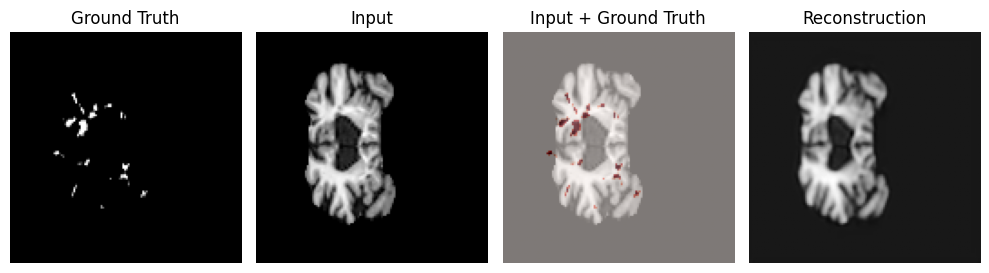

In [42]:
# Visualization of reconstructions 
t1_input_np = image.cpu().numpy()
t1_recon_np = reconstruction.cpu().numpy()
t1_anomaly = filtered_residual.numpy()

# t2_inputs_np = input_2.cpu().numpy()
# t2_recon_np = output_2.cpu().numpy()
# t2_original_np = gt_2.cpu().numpy()
# t2_anomaly = filtered_residual_2.cpu().numpy()

# Create subplots with 2 rows (T1 and T2) and 3 columns (Ground Truth, Input, Reconstruction)
fig, axes = plt.subplots(1, 4, figsize=(10, 5))

# Select the first sample (index 0)
i = 0  

# Extract middle slices along depth
t1_ori_slice = ground_truth[i, :, 50, :]  
t1_mid_slice = t1_input_np[i, 0, :, 50, :] # t1_inputs_np.shape[-1] // 2
t1_recon_slice = t1_recon_np[i, 0, :, 50, :]

# t2_ori_slice = t2_original_np[i, 0, 50, :, :]
# t2_mid_slice = t2_inputs_np[i, 0, 50, :, :]
# t2_recon_slice = t2_recon_np[i, 0, 50, :, :]
# t2_anomaly_slice = t2_anomaly[i, 0, 50, :, :]

# Plot T1 slices (row 0)
axes[0].imshow(t1_ori_slice, cmap="gray")  
axes[1].imshow(t1_mid_slice, cmap="gray") 
axes[2].imshow(t1_mid_slice, cmap="gray") 
axes[2].imshow(t1_ori_slice, cmap="Reds", alpha=0.5) 
axes[3].imshow(t1_recon_slice, cmap="gray")
# axes[4].imshow(t1_anomaly_slice, cmap="hot")  

# Plot T2 slices (row 1)
# axes[1, 0].imshow(t2_ori_slice, cmap="gray")  
# axes[1, 1].imshow(t2_mid_slice, cmap="gray")  
# axes[1, 2].imshow(t2_mid_slice, cmap="gray")  
# axes[1, 2].imshow(t2_ori_slice, cmap="Reds", alpha=0.5) 
# axes[1, 3].imshow(t2_recon_slice, cmap="gray") 
# axes[1, 4].imshow(t2_anomaly_slice, cmap="hot") 

# Remove axis labels
# for row in range(1):
for col in range(4):
    axes[col].axis("off")

# Set column titles
axes[0].set_title("Ground Truth")
axes[1].set_title("Input")
axes[2].set_title("Input + Ground Truth")
axes[3].set_title("Reconstruction")
# axes[4].set_title("Anomaly")

# Add row labels (T1 and T2) using fig.text()
# fig.text(0.05, 0.75, "T1 MRI", fontsize=12, fontweight="bold", va="center", rotation=90)
# fig.text(0.05, 0.25, "T2 MRI", fontsize=12, fontweight="bold", va="center", rotation=90)

plt.tight_layout()
plt.show()

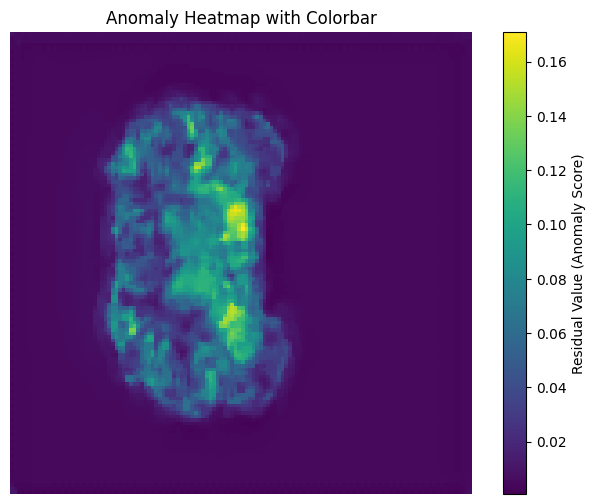

In [43]:
t1_anomaly_slice = t1_anomaly[:, 50, :]
# Plot heatmap with colorbar
plt.figure(figsize=(8, 6))
heatmap = plt.imshow(t1_anomaly_slice, cmap="viridis")   # Create the heatmap using "hot" colormap
plt.colorbar(heatmap, label="Residual Value (Anomaly Score)")  # Add the colorbar with label
plt.title("Anomaly Heatmap with Colorbar")
plt.axis("off")
plt.show()

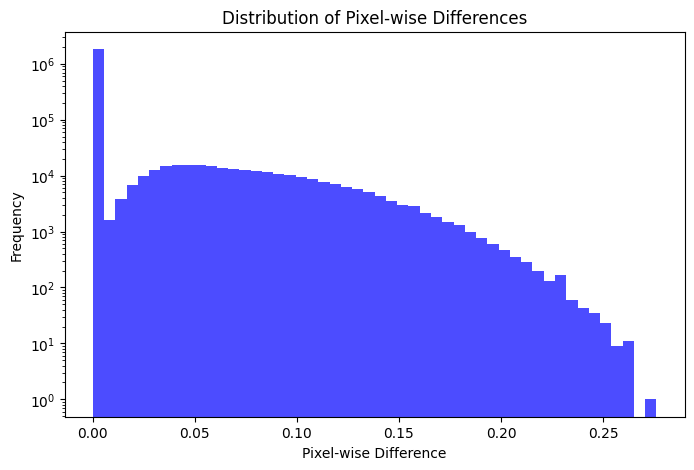

In [19]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# Compute absolute pixel-wise differences
# residual = (torch.abs(input_2 - output_2) * mask_2).cpu().numpy().flatten()  # Convert to NumPy & flatten

# Plot histogram
plt.figure(figsize=(8, 5))
plt.hist(filtered_residual_1.cpu().numpy().flatten(), bins=50, color='blue', alpha=0.7)  
plt.xlabel("Pixel-wise Difference")
plt.ylabel("Frequency")
plt.title("Distribution of Pixel-wise Differences")
plt.yscale("log")  # Log scale for better visibility (optional)
plt.show()


In [3]:
from src.inference import prediction

In [4]:
mri_path = r"C:\Users\hp\Downloads\MSLUB-T1\patient01_T1W.nii.gz"

In [5]:
image, anomaly = prediction(mri_path, 1)

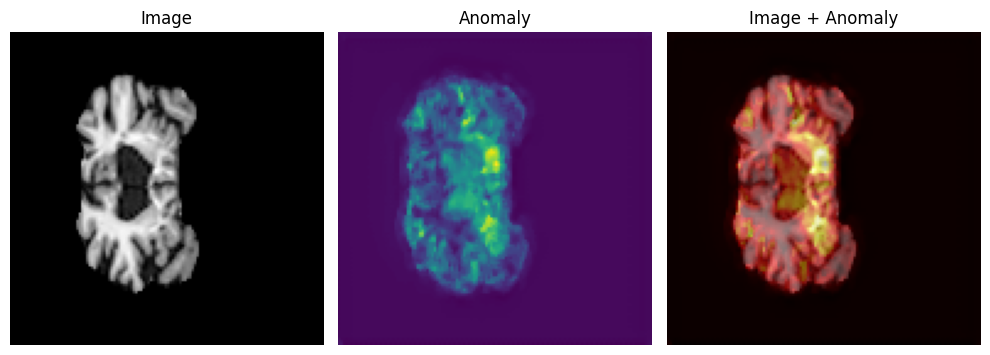

In [14]:
# Visualization of reconstructions 
t1_input_np = image.cpu().numpy()
t1_anomaly = anomaly.numpy()

fig, axes = plt.subplots(1, 3, figsize=(10, 5))

# Extract middle slices along depth
t1_anomaly = t1_anomaly[:, 50, :]  
t1_mid_slice = t1_input_np[0, 0, :, 50, :] 

# Plot T1 slices (row 0)
axes[0].imshow(t1_mid_slice, cmap="gray")  
axes[1].imshow(t1_anomaly, cmap="viridis") 
axes[2].imshow(t1_mid_slice, cmap="gray") 
axes[2].imshow(t1_anomaly, cmap="hot", alpha=0.5) 

for col in range(3):
    axes[col].axis("off")

# Set column titles
axes[0].set_title("Image")
axes[1].set_title("Anomaly")
axes[2].set_title("Image + Anomaly")

plt.tight_layout()
plt.show()